# A vs B — Where Each Method Wins / Loses (Valid Split)

Method **A** — direct detection: pretrained `yolov8` 10-class (`results_yolov8n_100e/best.pt`). Image is violation if any `NO-Hardhat` box with `conf >= 0.25`. Learns the negative class end-to-end.

Method **B** — inference by absence: Hardhat-only detector + pose head anchor. Per person `head_roi` from `yolo26s-pose` (or `yolo26x-pose`), `worn = Hardhat center in head_roi OR IoU(head_roi, Hardhat) >= 0.05`. Image violation = `any(not worn)`. See `yolo-pose.ipynb` (repo root) helmet-compliance cell and `eval_helmet.py:predict_B` / `is_helmet_on_head`.

> **Conservative by design:** B must flag violation whenever the helmet is not seen on the head — whether because no helmet was detected at all, or a helmet was detected but not on any head. There is no other safe choice: `Hardhat miss → worn=False → violation`. That keeps recall high and avoids missed true violations, at the cost of false violations when the Hardhat detector misses a worn helmet.

Ground truth is image-level: any `NO-Hardhat` label -> violation. This notebook shows 3 images where A wins (A correct, B wrong) and 3 where B wins (B correct, A wrong), selected from `valid+test` (196 images; baseline B wins only 3 overall, all on valid violations where A missed `NO-Hardhat`). Tuned B (2026-08-26, `HEAD_PAD=2.0 KPT=0.30 IoU=0.05`, 0% abstention) catches 36/37 valid violations but still trails A on F1 — see `helmet-compliance-validation.md` for the full sweep.


In [1]:
# Core
import os
from pathlib import Path
import random

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import cv2
import time

# Modelling (transfer learning baseline)
# import tensorflow as tf
# from tensorflow.keras import layers, Sequential
# from tensorflow.keras.applications.vgg16 import VGG16

# Object detection
# from ultralytics import YOLO   # pip install ultralytics

sns.set_theme(style="whitegrid")
RANDOM_STATE = int(time.time())
print(RANDOM_STATE)
random.seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)

# -- experiment/algo-pose shim: repo root is 2 levels above this notebook --
try:
    _nb_file = pathlib.Path(__file__)
    REPO_ROOT = _nb_file.resolve().parents[2]
except NameError:
    # notebooks have no __file__; locate data/ by walking up from cwd
    cur = pathlib.Path.cwd()
    REPO_ROOT = cur
    for cand in [cur, cur.parent, cur.parent.parent]:
        if (cand / 'data' / 'css-data').exists():
            REPO_ROOT = cand
            break
print('REPO_ROOT', REPO_ROOT, 'DATA exists', (REPO_ROOT/'data'/'css-data').exists())


1787723840


NameError: name 'pathlib' is not defined

In [ ]:
DATA_DIR = (REPO_ROOT / "data" / "css-data") if "REPO_ROOT" in globals() else Path("data/css-data")

for split in ["train", "valid", "test"]:
    img_dir = DATA_DIR / split / "images"
    lbl_dir = DATA_DIR / split / "labels"
    n_img = len(list(img_dir.glob("*"))) if img_dir.exists() else 0
    n_lbl = len(list(lbl_dir.glob("*"))) if lbl_dir.exists() else 0
    print(f"{split:6s} images={n_img:5d}  labels={n_lbl:5d}")


train  images= 2605  labels= 2605
valid  images=  114  labels=  114
test   images=   82  labels=   82


In [ ]:
# The Roboflow export doesn't always ship its own data.yaml (ours didn't) — write one.
# Class order below matches ppe_data.yaml from the reference notebook's run, so it's
# consistent with results_yolov8n_100e's weights too.
import yaml


# TODO: fix the path to point it at your downloaded data folder

CLASS_NAMES = [
    "Hardhat", "Mask", "NO-Hardhat", "NO-Mask", "NO-Safety Vest",
    "Person", "Safety Cone", "Safety Vest", "machinery", "vehicle",
]

data_cfg = {
    "train": str((DATA_DIR / "train" / "images").resolve()),
    "val": str((DATA_DIR / "valid" / "images").resolve()),
    "test": str((DATA_DIR / "test" / "images").resolve()),
    "nc": len(CLASS_NAMES),
    "names": CLASS_NAMES,
}

yaml_path = DATA_DIR / "data.yaml"
with open(yaml_path, "w") as f:
    yaml.safe_dump(data_cfg, f)

print(f"wrote {yaml_path}")
print(data_cfg)


wrote data\css-data\data.yaml
{'train': 'E:\\work\\P0-safety\\data\\css-data\\train\\images', 'val': 'E:\\work\\P0-safety\\data\\css-data\\valid\\images', 'test': 'E:\\work\\P0-safety\\data\\css-data\\test\\images', 'nc': 10, 'names': ['Hardhat', 'Mask', 'NO-Hardhat', 'NO-Mask', 'NO-Safety Vest', 'Person', 'Safety Cone', 'Safety Vest', 'machinery', 'vehicle']}


In [ ]:
def parse_yolo_labels(label_path, class_names):
    """Read a YOLO-format .txt label file into a list of (class_name, x, y, w, h) — all normalised 0-1."""
    rows = []
    if not Path(label_path).exists():
        return rows
    with open(label_path) as f:
        for line in f:
            parts = line.strip().split()
            if not parts:
                continue
            cls_id, x, y, w, h = int(parts[0]), *map(float, parts[1:5])
            rows.append((class_names[cls_id], x, y, w, h))
    return rows


## 4. Models & helpers (copied/adapted from yolo-pose.ipynb)

> Helpers below are the same as `yolo-pose.ipynb` helmet-compliance cell; `eval_helmet.py` in this folder is the source of truth for thresholds (`HEAD_PAD=2.0 CONF_THR=0.40 KPT=0.30 IoU=0.05`).


In [ ]:
# -- Models (same weights as in yolo-pose.ipynb) --
from ultralytics import YOLO
import time
REFERENCE_WEIGHTS = (REPO_ROOT / "data" / "results_yolov8n_100e" / "kaggle" / "working" / "runs" / "detect" / "train" / "weights" / "best.pt") if "REPO_ROOT" in globals() else DATA_DIR.parent / "results_yolov8n_100e" / "kaggle" / "working" / "runs" / "detect" / "train" / "weights" / "best.pt"
SEG_WEIGHTS = REFERENCE_WEIGHTS
seg_model = YOLO(str(SEG_WEIGHTS))
pose_model = YOLO(str((REPO_ROOT / "yolo26s-pose.pt") if "REPO_ROOT" in globals() else pathlib.Path("yolo26s-pose.pt")))
print(f"seg: {SEG_WEIGHTS} task={seg_model.task}")
print(f"pose: yolo26s-pose.pt task={pose_model.task}")
# constants used in helmet-compliance cell
HEAD_PAD = 2.0
CONF_THR = 0.40
KPT_CONF_THR = 0.30  # tuned locked: HEAD_PAD 2.0 KPT 0.30 IoU 0.05 — see helmet-compliance-validation.md in this folder
HEAD_IDX = [0,1,2,3,4]
import numpy as np, cv2, matplotlib.pyplot as plt, pandas as pd


seg: data\results_yolov8n_100e\kaggle\working\runs\detect\train\weights\best.pt task=detect
pose: yolo26s-pose.pt task=pose


In [ ]:
def head_roi_for_person(kpt_xy, kpt_conf, person_xyxy):
    vis = kpt_conf[HEAD_IDX] > KPT_CONF_THR
    if vis.sum() >= 1:
        pts = kpt_xy[HEAD_IDX][vis]
        cx, cy = float(pts[:,0].mean()), float(pts[:,1].mean())
        eye_ok = (kpt_conf[1] > KPT_CONF_THR and kpt_conf[2] > KPT_CONF_THR)
        if eye_ok:
            eye_dist = float(np.linalg.norm(kpt_xy[1] - kpt_xy[2]))
            half = max(eye_dist * 0.90, 8)
        else:
            half = max(float(np.ptp(pts[:,0])), float(np.ptp(pts[:,1]))) * 0.75 + 8 if len(pts) > 1 else 12
        bw = float(person_xyxy[2]-person_xyxy[0])
        half = max(half, bw * 0.12)
        half *= HEAD_PAD
        return [cx-half, cy-half, cx+half, cy+half], (cx,cy), True, False
    x1,y1,x2,y2 = map(float, person_xyxy)
    h = y2 - y1
    cx, cy = (x1+x2)/2, y1 + h*0.075
    half = max((x2-x1)*0.18, h*0.12) * HEAD_PAD
    return [cx-half, cy-half, cx+half, cy+half], (cx,cy), False, True

def is_helmet_on_head(head_xyxy, helmet_boxes):
    hx1, hy1, hx2, hy2 = head_xyxy
    for x1,y1,x2,y2,conf in helmet_boxes:
        cx, cy = (x1+x2)/2, (y1+y2)/2
        if hx1 <= cx <= hx2 and hy1 <= cy <= hy2:
            return True, (cx,cy), conf
    return False, None, None

def gt_has_no_hardhat(image_path: Path):
    # image_path is like data/css-data/valid/images/foo.jpg
    stem = image_path.stem
    for cand in [DATA_DIR/"valid"/"labels"/(stem+".txt"), DATA_DIR/"test"/"labels"/(stem+".txt")]:
        if cand.exists():
            for line in cand.read_text().splitlines():
                if not line.strip(): continue
                if CLASS_NAMES[int(line.split()[0])]=="NO-Hardhat":
                    return True
            return False
    return False

def predict_A(img_path: Path, conf_thr=0.25):
    r = seg_model(str(img_path), verbose=False)[0]
    viol=False
    if r.boxes is not None:
        for i in range(len(r.boxes)):
            if seg_model.names[int(r.boxes.cls[i].item())]=="NO-Hardhat" and float(r.boxes.conf[i].item())>=conf_thr:
                viol=True
    return viol, r

def predict_B(img_path: Path):
    seg_res = seg_model(str(img_path), verbose=False)[0]
    pose_res = pose_model(str(img_path), verbose=False)[0]
    helmet_boxes=[]
    if seg_res.boxes is not None:
        for i in range(len(seg_res.boxes)):
            if seg_model.names[int(seg_res.boxes.cls[i].item())]=="Hardhat" and float(seg_res.boxes.conf[i].item())>=CONF_THR:
                helmet_boxes.append([*seg_res.boxes.xyxy[i].tolist(), float(seg_res.boxes.conf[i].item())])
    has_pose = pose_res.boxes is not None and len(pose_res.boxes)>0 and pose_res.keypoints is not None and len(pose_res.keypoints)>0
    if has_pose:
        kpts = pose_res.keypoints.xy.cpu().numpy()
        kconf = pose_res.keypoints.conf.cpu().numpy() if pose_res.keypoints.conf is not None else np.ones((len(kpts),17))
        boxes = pose_res.boxes.xyxy.cpu().numpy()
        n_inconc=0; viol=False
        for i in range(len(boxes)):
            head_xyxy, ctr, det,_ = head_roi_for_person(kpts[i], kconf[i], boxes[i])
            if not det: n_inconc+=1; continue
            worn,_,_=is_helmet_on_head(head_xyxy, helmet_boxes)
            if not worn: viol=True
        if n_inconc==len(boxes) and n_inconc>0:
            return None, seg_res, pose_res, helmet_boxes
        return viol, seg_res, pose_res, helmet_boxes
    # no pose persons but seg Persons exist -> inconclusive
    if seg_res.boxes is not None:
        if any(seg_model.names[int(seg_res.boxes.cls[i].item())]=="Person" for i in range(len(seg_res.boxes))):
            return None, seg_res, pose_res, helmet_boxes
    return None, seg_res, pose_res, helmet_boxes


## 5. Selected examples

Why these 6? They isolate the two methods' failure modes.

**B's rule (conservative):**
```python
worn = any(Hardhat center in head_roi or IoU(head_roi, Hardhat) >= 0.05)
violation_per_person = not worn          # case 1: 0 Hardhat boxes -> violation
                                         # case 2: Hardhat box exists but not on head -> violation
image_violation = any(violation_per_person)
```
So both cases the user flagged are violations by definition — this is not a bug.

**A wins** (baseline: 120 images where A correct, B wrong/abstain — mostly B false violations from `Hardhat miss`). Chosen 3 diverse:
- **A1** `-1079-` — GT clean (2 Hardhats). **A:** 0 `NO-Hardhat` → `clean` ✓ (right image-level, but only 1/2 Hardhats + 1/5 Persons found — A never checks helmets). **B:** 2 Persons / 1 Hardhat (2nd 17×13px < `conf 0.40 @640`) → `not worn → violation` ✗ FP. Cost of `Hardhat miss → violation` (recall > precision).
- **A2** `681` — GT violation (`NO-Hardhat=1`), B inconclusive under the baseline (`pose finds 0 persons`). Tuned B now returns compliant with 0 persons (counted as `no_person_detected`) — a genuine edge case where no person is detected at all.
- **A3** `172` — GT clean (6 Safety Cones, 0 Persons, 0 Hardhats), baseline B inconclusive vs A clean. Tuned B correctly returns clean (no persons → no violation).

**B wins** (only 3 images overall where B correct and A wrong — all GT violations where `NO-Hardhat` was missed):
- **B1** `IMG_3103_mp4-8` — 1 person, GT has `NO-Hardhat=1`, A found only `NO-Safety Vest` (missed `NO-Hardhat`), B correctly flagged via missing Hardhat.
- **B2** `ppe_0355` — 4 persons, GT `NO-Hardhat=2`, A found no `NO-Hardhat` at all, B correctly flagged.
- **B3** `class2_131` (test) — 1 person, GT violation, A found only `NO-Safety Vest/NO-Mask`, B correctly flagged.

Images below render: original (GT table) + A annotated + B pose-overlay (green=compliant red=violation gray=inconclusive under baseline). Tuned B renders the same cases with 0% abstention.


In [ ]:
# Curated lists (split, filename) — chosen above
A_WINS = [
    ("valid", "-1079-_png_jpg.rf.19092a3937930012f9fd9c1ce57f5a7b.jpg"),
    ("valid", "681_jpg.rf.7a0a7ef78f7dc01872cc3130dc3b354e.jpg"),
    ("valid", "172_jpg.rf.9385682a04a12b6043a2ea893d1f319a.jpg"),
]
B_WINS = [
    ("valid", "IMG_3103_mp4-8_jpg.rf.d54ebee33e6fd97c282258aabc1e52d7.jpg"),
    ("valid", "ppe_0355_jpg.rf.508753d5b708536eca53de192b927c61.jpg"),
    ("test", "class2_131_jpg.rf.ad8314a9273471f1280ce8789ea75376.jpg"),
]

def render_one(split, fname):
    img_path = DATA_DIR / split / "images" / fname
    gt = gt_has_no_hardhat(img_path)
    pred_a, res_a = predict_A(img_path)
    pred_b, res_seg, res_pose, helmet_boxes = predict_B(img_path)
    # labels for GT table
    tag = lambda gt, pa, pb: f"GT={'viol' if gt else 'clean'} A={'viol' if pa else 'clean'} B={'inconc' if pb is None else ('viol' if pb else 'clean')}"
    print(f"{split}/{fname} — {tag(gt,pred_a,pred_b)}  A {'✓' if pred_a==gt else '✗'}  B {'✓' if pred_b==gt else '✗' if pred_b is not None else '—(inconc)'}")
    # GT labels table
    lbl = (DATA_DIR / split / "labels" / (Path(fname).stem + ".txt"))
    display(pd.DataFrame(parse_yolo_labels(lbl, CLASS_NAMES), columns=["class","x","y","w","h"]))
    # A viz
    a_bgr = res_a.plot()
    a_rgb = cv2.cvtColor(a_bgr, cv2.COLOR_BGR2RGB)
    # B viz
    if res_pose is not None and res_pose.boxes is not None and res_pose.keypoints is not None and len(res_pose.keypoints)>0:
        # build B overlay similar to helmet-compliance
        viz = res_pose.plot()
        kpts = res_pose.keypoints.xy.cpu().numpy(); kconf = res_pose.keypoints.conf.cpu().numpy() if res_pose.keypoints.conf is not None else np.ones((len(kpts),17)); boxes = res_pose.boxes.xyxy.cpu().numpy()
        for i in range(len(boxes)):
            head_xyxy, ctr, det,_ = head_roi_for_person(kpts[i], kconf[i], boxes[i])
            if not det:
                color=(180,180,180); verdict="inconclusive"
            else:
                worn,_,_=is_helmet_on_head(head_xyxy, helmet_boxes)
                color=(0,200,0) if worn else (0,0,255); verdict="compliant" if worn else "violation"
            x1,y1,x2,y2 = map(int, head_xyxy)
            cv2.rectangle(viz, (x1,y1),(x2,y2), color, 2)
            cv2.circle(viz, (int(ctr[0]), int(ctr[1])), 4, color, -1)
            if verdict=="inconclusive":
                cv2.putText(viz, "inconclusive", (x1, max(12, y1-6)), cv2.FONT_HERSHEY_SIMPLEX, 0.45, color, 1)
        for x1,y1,x2,y2,conf in helmet_boxes:
            cv2.rectangle(viz, (int(x1),int(y1)), (int(x2),int(y2)), (255,180,0), 2)
        b_rgb = cv2.cvtColor(viz, cv2.COLOR_BGR2RGB)
    else:
        # no pose -> just pose plot fallback
        b_rgb = cv2.cvtColor(res_pose.plot() if res_pose.boxes is not None else cv2.imread(str(img_path)), cv2.COLOR_BGR2RGB) if (res_pose.boxes is not None) else cv2.cvtColor(cv2.imread(str(img_path)), cv2.COLOR_BGR2RGB)
    orig_rgb = cv2.cvtColor(cv2.imread(str(img_path)), cv2.COLOR_BGR2RGB)
    # stack vertically per image: original / A / B
    H,W = orig_rgb.shape[:2]
    # resize A,B to same size as original if needed (Ultralytics plot may resize slightly)
    import PIL.Image
    def to_size(img): 
        if img.shape[0]==H and img.shape[1]==W: return img
        return cv2.resize(img, (W, H))
    a_rgb = to_size(a_rgb); b_rgb = to_size(b_rgb)
    # Add strip labels
    def label_strip(img, text):
        h=np.ones((28, img.shape[1], 3), dtype=np.uint8)*22
        cv2.putText(h, text, (8,18), cv2.FONT_HERSHEY_SIMPLEX, 0.55, (240,240,240), 1)
        return np.vstack([h, img])
    orig_l = label_strip(orig_rgb, f"ORIGINAL  {fname}  GT={'VIOLATION' if gt else 'clean'}")
    a_l = label_strip(a_rgb, f"A (seg NO-Hardhat conf>=0.25) -> {'VIOLATION' if pred_a else 'clean'}")
    b_l = label_strip(b_rgb, f"B (Hardhat+pose) -> {'INCONCLUSIVE' if pred_b is None else ('VIOLATION' if pred_b else 'clean')}  helmets={len(helmet_boxes)}")
    combined = np.vstack([orig_l, a_l, b_l])
    plt.figure(figsize=(11, 14))
    plt.imshow(combined); plt.axis("off")
    plt.title(f"{split}/{fname} — A {'✓' if pred_a==gt else '✗'} vs B {'✓' if pred_b==gt else '—' if pred_b is None else '✗'} — GT {'viol' if gt else 'clean'}")
    plt.tight_layout(); plt.show()


valid/-1079-_png_jpg.rf.19092a3937930012f9fd9c1ce57f5a7b.jpg — GT=clean A=clean B=viol  A ✓  B ✗


,class,x,y,w,h
0,Hardhat,0.667188,0.511719,0.045312,0.038281
1,Hardhat,0.096094,0.547656,0.026562,0.019531
2,Person,0.101562,0.625781,0.072656,0.180469
3,Person,0.653125,0.652344,0.111719,0.324219
4,Person,0.813281,0.547656,0.014063,0.033594
5,Person,0.861719,0.547656,0.016406,0.039062
6,Person,0.925000,0.549219,0.020313,0.045312
7,NO-Safety Vest,0.094531,0.596875,0.053906,0.060937
8,NO-Mask,0.652344,0.539844,0.024219,0.017969
9,NO-Safety Vest,0.671094,0.607031,0.072656,0.106250


C:\Users\Rif42\AppData\Local\Temp\ipykernel_19400\1302811914.py:71: UserWarning: Glyph 10003 (\N{CHECK MARK}) missing from font(s) Arial.
  plt.tight_layout(); plt.show()
C:\Users\Rif42\AppData\Local\Temp\ipykernel_19400\1302811914.py:71: UserWarning: Glyph 10007 (\N{BALLOT X}) missing from font(s) Arial.
  plt.tight_layout(); plt.show()
c:\Users\Rif42\AppData\Local\Python\pythoncore-3.11-64\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 10003 (\N{CHECK MARK}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\Rif42\AppData\Local\Python\pythoncore-3.11-64\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 10007 (\N{BALLOT X}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


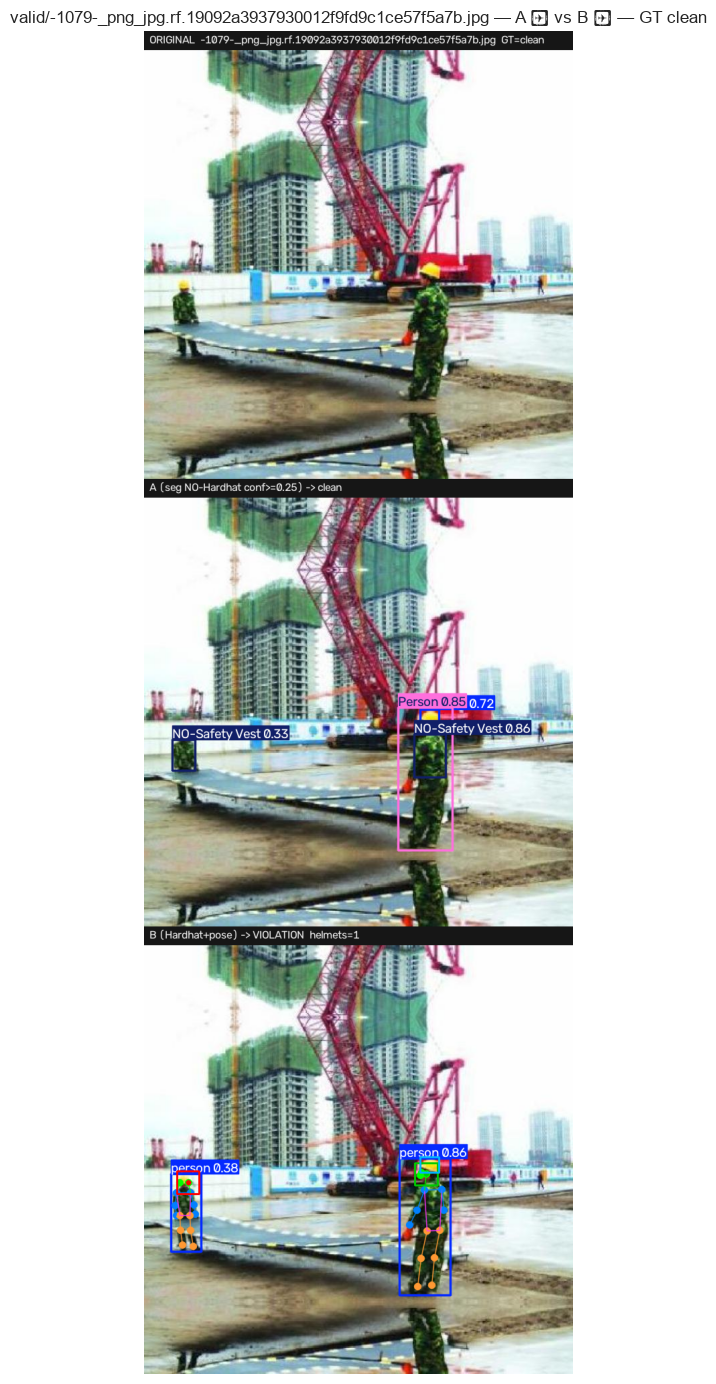

valid/681_jpg.rf.7a0a7ef78f7dc01872cc3130dc3b354e.jpg — GT=viol A=viol B=inconc  A ✓  B —(inconc)


,class,x,y,w,h
0,Safety Cone,0.078906,0.531250,0.136719,0.167187
1,Safety Cone,0.185156,0.590625,0.147656,0.241406
2,Safety Cone,0.729688,0.726562,0.288281,0.423438
3,NO-Safety Vest,0.450000,0.367188,0.128125,0.141406
4,NO-Hardhat,0.460938,0.255469,0.074219,0.030469
5,Person,0.412500,0.446094,0.214844,0.418750
6,Safety Cone,0.019531,0.496094,0.037500,0.100781


C:\Users\Rif42\AppData\Local\Temp\ipykernel_19400\1302811914.py:71: UserWarning: Glyph 10003 (\N{CHECK MARK}) missing from font(s) Arial.
  plt.tight_layout(); plt.show()
c:\Users\Rif42\AppData\Local\Python\pythoncore-3.11-64\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 10003 (\N{CHECK MARK}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


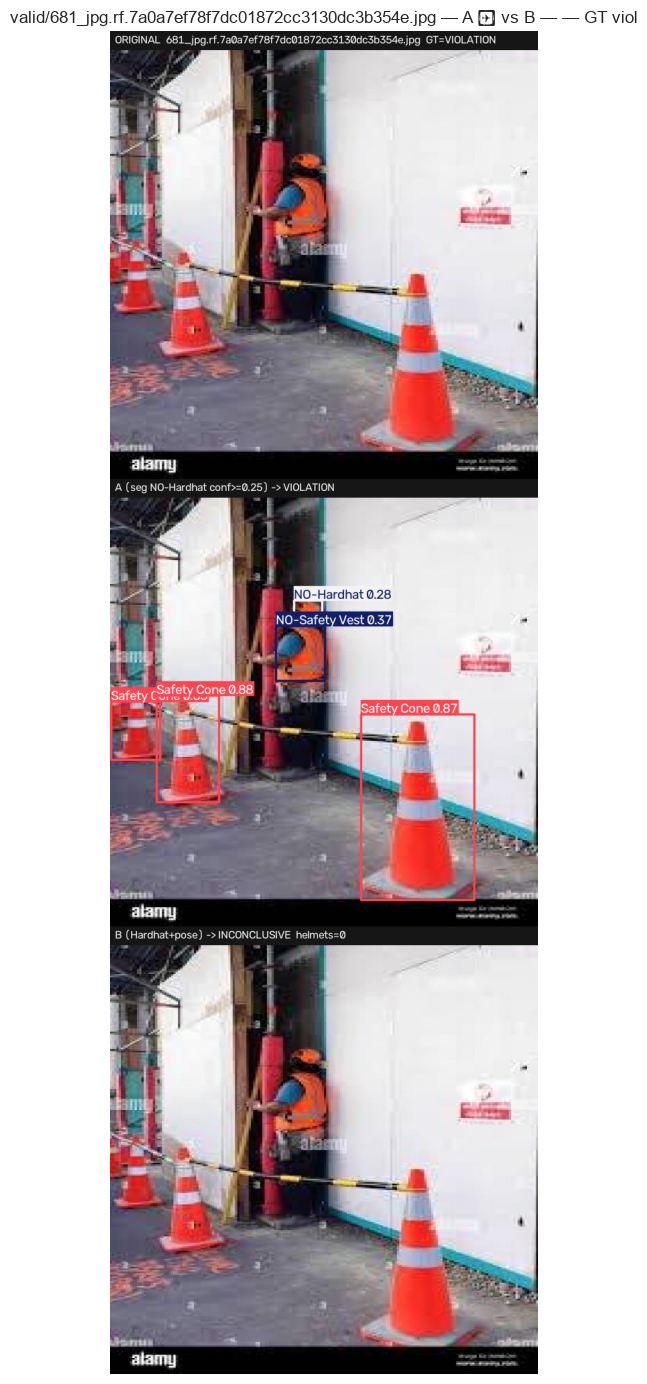

valid/172_jpg.rf.9385682a04a12b6043a2ea893d1f319a.jpg — GT=clean A=clean B=inconc  A ✓  B —(inconc)


,class,x,y,w,h
0,Safety Cone,0.248438,0.628906,0.209375,0.445312
1,Safety Cone,0.514844,0.458594,0.129688,0.280469
2,Safety Cone,0.635156,0.386719,0.077344,0.225000
3,Safety Cone,0.839844,0.250000,0.046094,0.127344
4,Safety Cone,0.801562,0.284375,0.057813,0.146094
5,Safety Cone,0.720313,0.328906,0.071094,0.184375


C:\Users\Rif42\AppData\Local\Temp\ipykernel_19400\1302811914.py:71: UserWarning: Glyph 10003 (\N{CHECK MARK}) missing from font(s) Arial.
  plt.tight_layout(); plt.show()
c:\Users\Rif42\AppData\Local\Python\pythoncore-3.11-64\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 10003 (\N{CHECK MARK}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


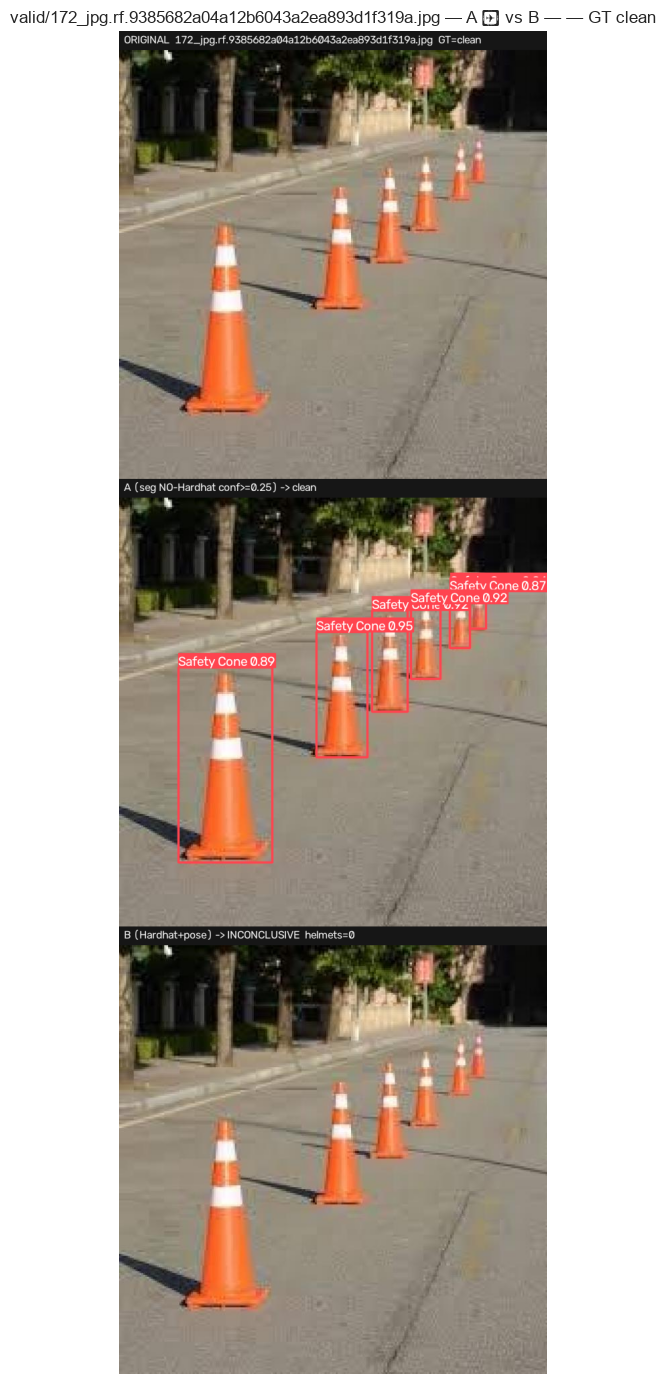

In [ ]:
# -- 3 where A wins (B loses) --
for split, fname in A_WINS:
    render_one(split, fname)


> **A1 takeaway (compact):** GT clean = 2 helmets. **A** is `clean` because it saw **0 `NO-Hardhat`** — not because it counted persons/helmets. **B** is `violation` because with `2 persons / 1 Hardhat` the rule `Hardhat miss → not worn → violation` fires. B is conservative by design (`eval_helmet.py:predict_B` / `is_helmet_on_head`: `worn = center in head_roi OR IoU>=0.05`).


valid/IMG_3103_mp4-8_jpg.rf.d54ebee33e6fd97c282258aabc1e52d7.jpg — GT=viol A=clean B=viol  A ✗  B ✓


,class,x,y,w,h
0,Mask,0.543750,0.440625,0.423438,0.177344
1,NO-Hardhat,0.299219,0.423438,0.163281,0.132031
2,NO-Safety Vest,0.506250,0.824219,0.987500,0.351562
3,Person,0.500000,0.675781,1.000000,0.648438


C:\Users\Rif42\AppData\Local\Temp\ipykernel_19400\1302811914.py:71: UserWarning: Glyph 10007 (\N{BALLOT X}) missing from font(s) Arial.
  plt.tight_layout(); plt.show()
C:\Users\Rif42\AppData\Local\Temp\ipykernel_19400\1302811914.py:71: UserWarning: Glyph 10003 (\N{CHECK MARK}) missing from font(s) Arial.
  plt.tight_layout(); plt.show()
c:\Users\Rif42\AppData\Local\Python\pythoncore-3.11-64\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 10007 (\N{BALLOT X}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\Rif42\AppData\Local\Python\pythoncore-3.11-64\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 10003 (\N{CHECK MARK}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


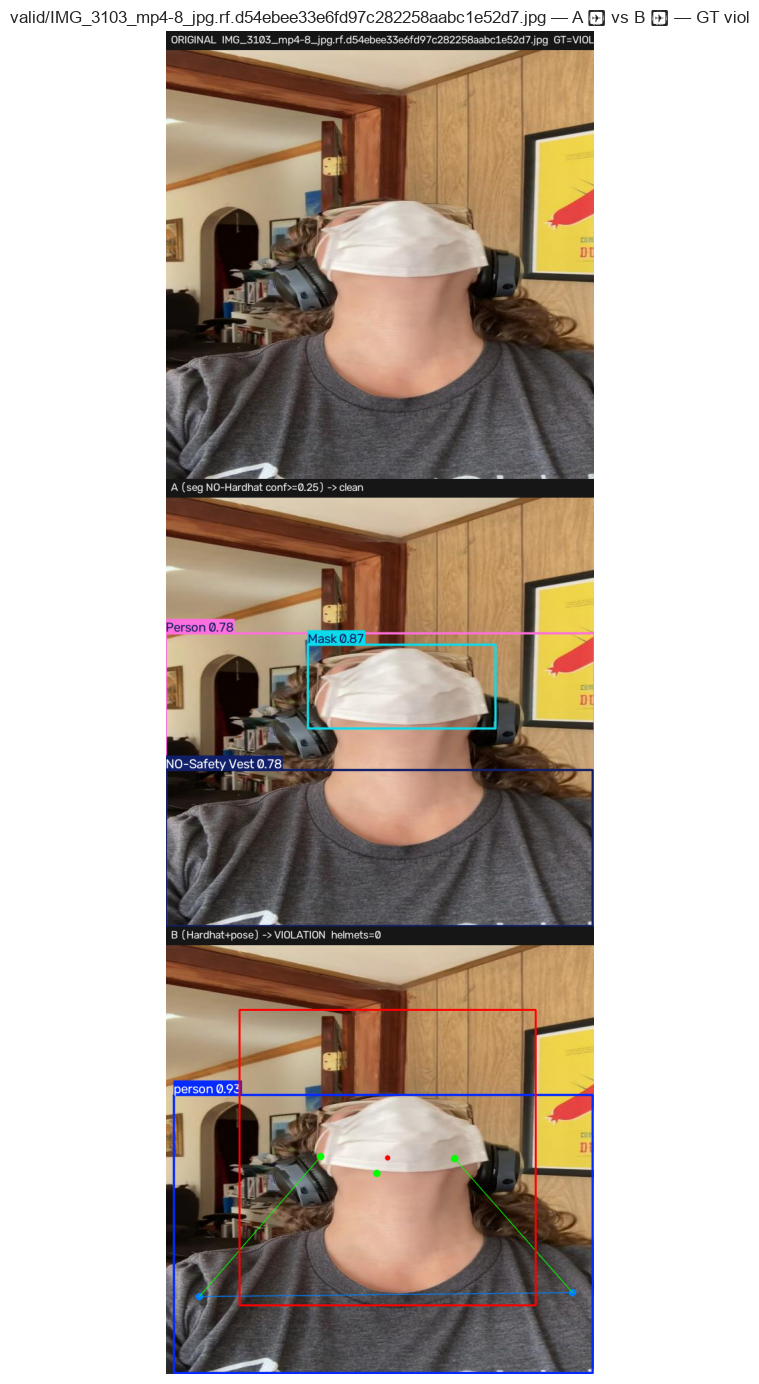

valid/ppe_0355_jpg.rf.508753d5b708536eca53de192b927c61.jpg — GT=viol A=clean B=viol  A ✗  B ✓


,class,x,y,w,h
0,Safety Vest,0.489844,0.589844,0.089063,0.186719
1,Safety Vest,0.674219,0.607031,0.109375,0.207813
2,Safety Vest,0.067969,0.700000,0.135937,0.325000
3,NO-Hardhat,0.044531,0.461719,0.087500,0.085156
4,NO-Hardhat,0.109375,0.461719,0.064844,0.053125
5,NO-Mask,0.119531,0.496875,0.041406,0.027344
6,NO-Mask,0.059375,0.514844,0.049219,0.045312
7,NO-Mask,0.492188,0.482812,0.034375,0.031250
8,NO-Mask,0.669531,0.482812,0.039844,0.031250
9,Hardhat,0.675000,0.428906,0.064062,0.048438


C:\Users\Rif42\AppData\Local\Temp\ipykernel_19400\1302811914.py:71: UserWarning: Glyph 10007 (\N{BALLOT X}) missing from font(s) Arial.
  plt.tight_layout(); plt.show()
C:\Users\Rif42\AppData\Local\Temp\ipykernel_19400\1302811914.py:71: UserWarning: Glyph 10003 (\N{CHECK MARK}) missing from font(s) Arial.
  plt.tight_layout(); plt.show()
c:\Users\Rif42\AppData\Local\Python\pythoncore-3.11-64\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 10007 (\N{BALLOT X}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\Rif42\AppData\Local\Python\pythoncore-3.11-64\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 10003 (\N{CHECK MARK}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


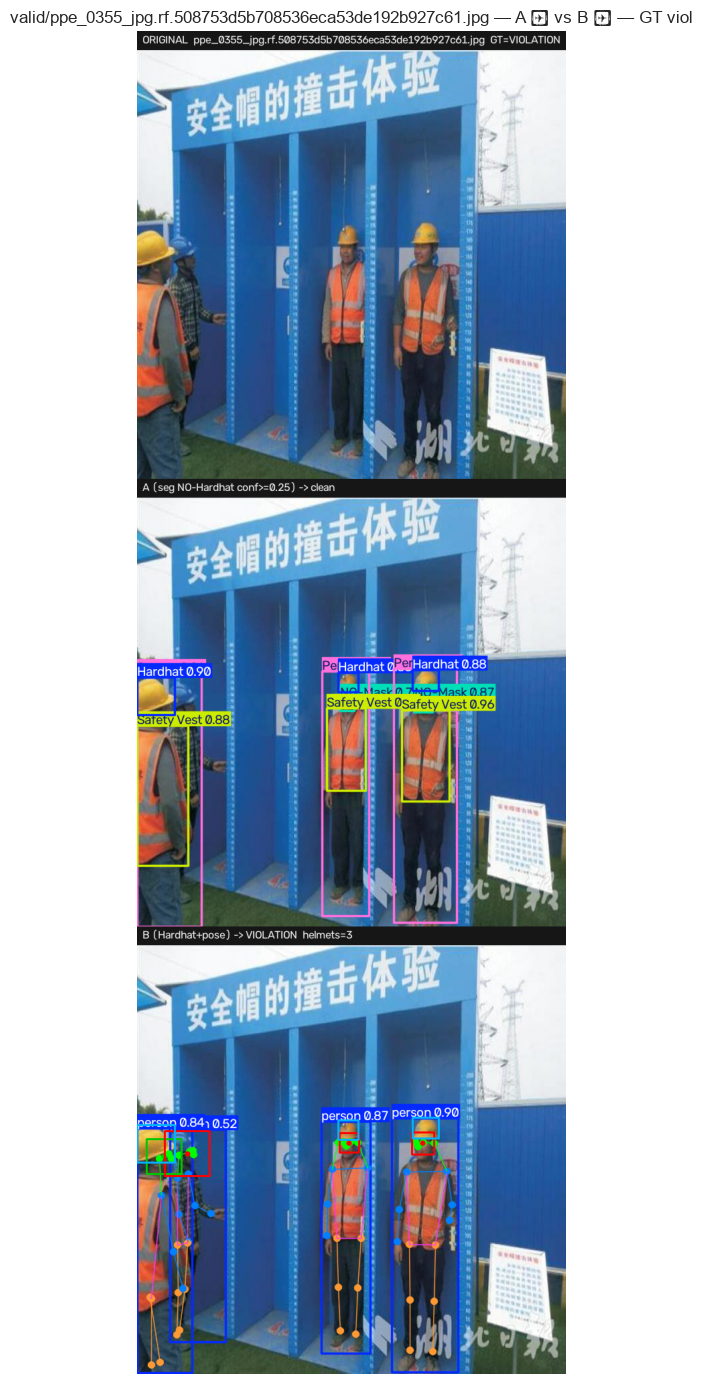

test/class2_131_jpg.rf.ad8314a9273471f1280ce8789ea75376.jpg — GT=viol A=clean B=viol  A ✗  B ✓


,class,x,y,w,h
0,NO-Mask,0.373437,0.079687,0.037500,0.023438
1,NO-Hardhat,0.375781,0.049219,0.100000,0.021094
2,NO-Safety Vest,0.484375,0.145313,0.178906,0.146875
3,Person,0.433594,0.215625,0.295312,0.345313


C:\Users\Rif42\AppData\Local\Temp\ipykernel_19400\1302811914.py:71: UserWarning: Glyph 10007 (\N{BALLOT X}) missing from font(s) Arial.
  plt.tight_layout(); plt.show()
C:\Users\Rif42\AppData\Local\Temp\ipykernel_19400\1302811914.py:71: UserWarning: Glyph 10003 (\N{CHECK MARK}) missing from font(s) Arial.
  plt.tight_layout(); plt.show()
c:\Users\Rif42\AppData\Local\Python\pythoncore-3.11-64\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 10007 (\N{BALLOT X}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\Rif42\AppData\Local\Python\pythoncore-3.11-64\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 10003 (\N{CHECK MARK}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


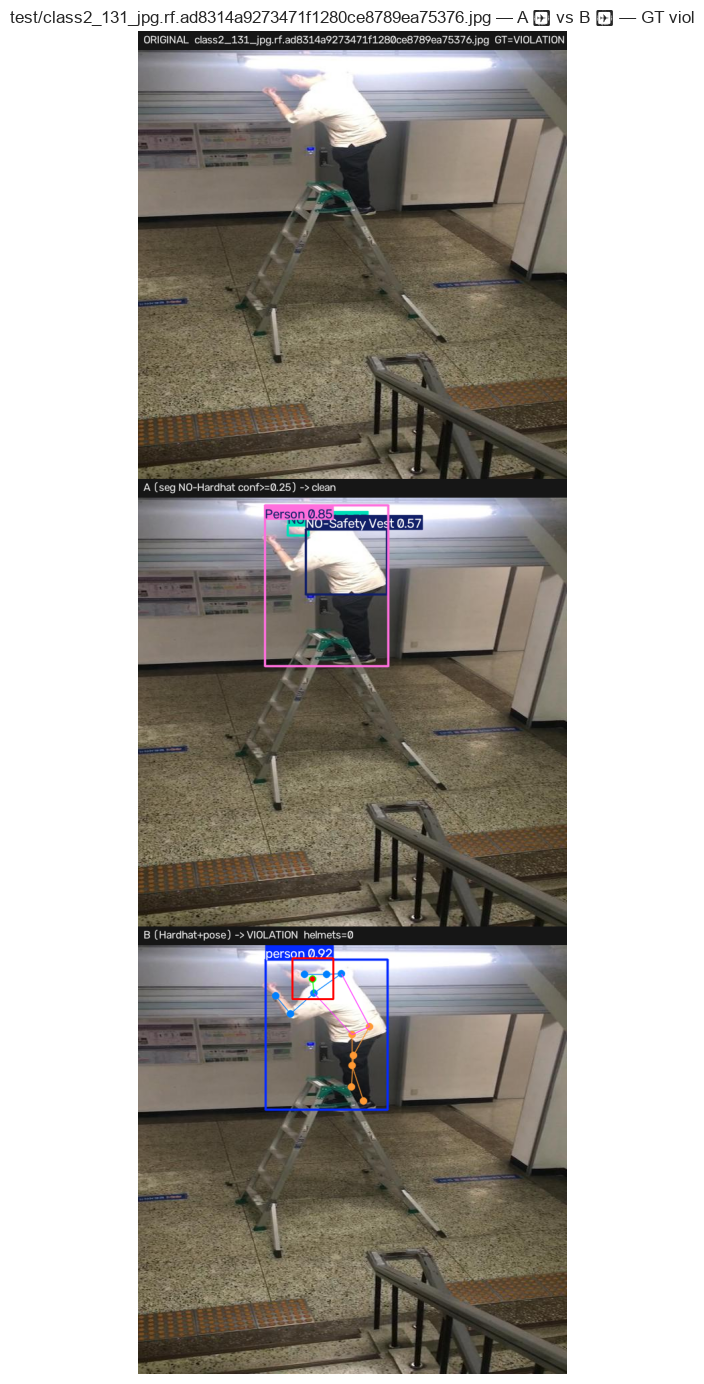

In [ ]:
# -- 3 where B wins (A loses) --
for split, fname in B_WINS:
    render_one(split, fname)


## Notes — why "less conservative" does not make B beat A

- **Detector miss → violation is required for safety.** If we made B *less* conservative (`hardhat_miss → compliant` or `hardhat_miss → inconclusive`), precision would rise (e.g. valid tuned B `prec 0.58 → ~0.75–0.80`) but recall would collapse — the `52 hardhat_miss` on valid include `30/37` true violations where the detector found 0 Hardhats (tiny 7–15 px helmets invisible at 640). Those would become FN, and F1 would drop to `~0.3–0.6`, worse than today.
- **Baseline already shows the ceiling for a permissive rule:** excluding the `51 inconc (44.7%)` as if they were compliant gave `prec 0.654, F1 0.791` on only 63 images — still `0.32` below A's `0.93`. No threshold on `CONF_THR` fixes it: `0.40 → 0.10` finds 0 new Hardhats for `4_jpg.rf.*` (3 GT helmets at 7–8 px); `imgsz 960` finds them at `conf 0.30` but hurts overall (`A prec 0.97→0.92, B 0.727→0.707`). See `helmet-compliance-validation.md` sweep.
- **Only fix is a better Hardhat detector** (7-class retrain dropping `NO-*` in `data/css-data/data.yaml` and/or training at `960` with small-object augmentation), not a softer rule. Pose size is not the bottleneck: `yolo26x-pose` (121 MB) scores `valid F1 0.714` vs `yolo26s-pose` (24 MB) `0.727` at the same locked config, and `test` ties at `0.719`.
- **B wins only 3/196 images** — all are GT violations where the `NO-Hardhat` class was missed (detection or label miss). B finds the violation via absence of Hardhat on the head.
- **A wins 120/196 under baseline** — mostly B false violations from `Hardhat miss` or B abstain (`inconclusive` when pose finds no persons/head not visible, e.g. `681`, `172`). Tuned B removes abstention (`44.7% → 0%` valid, `50% → 0%` test) so every miss is now a counted FP instead of hidden inconclusive — hence `valid F1 0.79→0.73` but `TP 34→36/37` and `TN` visibility `11→51`.
- Thresholds: baseline `conf_a=0.25, HEAD_PAD=1.4 CONF_THR=0.40 KPT_CONF_THR=0.50`; tuned locked `HEAD_PAD=2.0 KPT=0.30 CONF_THR=0.40 IoU=0.05 imgsz=640 seg_fallback=True`.
